## Basic routine

In [26]:
# Autoload modules
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [35]:
import sys
sys.path.append('../..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA, SLSQP
# from qiskit_algorithms.minimum_eigensolvers import SamplingVQE
# from qiskit.primitives import Sampler
import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Statevector
from sklearn.metrics import r2_score
import pickle

In [36]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [43]:
main_seq = "LHPGAGK" # YYDPETGTWY" # 10 AA chingolin
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op()
print("Number of qubits: ", qubit_op.num_qubits)
#print("Number of terms: ", len(qubit_op))
#print(qubit_op)

Number of qubits:  33


In [44]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
# print("Number of olap constr ops: ", len(bead_pairs))
# print(bead_pairs)
# print(olap_constr_ops[0].num_qubits == qubit_op.num_qubits)
# print(olap_constr_ops[0].num_qubits == olap_constr_ops[-1].num_qubits)

## VQE routine

In [45]:
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import NELDER_MEAD
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

In [46]:
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}


def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

In [47]:
def run_vqe_estimator(hamiltonian):
    hamiltonian = qubit_op #problem hamiltonian
    ansatz = RealAmplitudes(hamiltonian.num_qubits, reps=1) #choose your ansatz
    num_params = ansatz.num_parameters

    # aer_sim = AerSimulator(method='matrix_product_state') #to run locally
    # To run on hardware, select the backend with the fewest number of jobs in the queue
    service = QiskitRuntimeService(channel="ibm_quantum")
    backend = service.least_busy(operational=True, simulator=False)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3) #pass manager setup

    ansatz_isa = pm.run(ansatz) #transpile the circuit for the backend
    hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout) #apply layout to the hamiltonian as well
    

    x0 = 2 * np.pi * np.random.random(num_params)
    # x0 =  [np.pi/2] * num_params #select a random starting vector

    # Start the session with an estimator and find the minimum eigenvalue

    with Session(backend=backend) as session:
        estimator = Estimator(mode=session)
        estimator.options.default_shots = 5000

        res = minimize(
            cost_func,
            x0,
            args=(ansatz_isa, hamiltonian_isa, estimator),
            method="cobyla"
            
        )

    # options= {'maxiter':1000}
    # all(cost_history_dict["prev_vector"] == res.x)
    # cost_history_dict["iters"] == res.nfev

    # Plot the cost function over vqe
    fig, ax = plt.subplots()
    ax.plot(range(cost_history_dict["iters"]), cost_history_dict["cost_history"])
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Cost")
    plt.draw()

    # Solution is found, bind the optimal parameters to the ansatz
    ansatz_bind = ansatz.assign_parameters(res.x)
    ansatz_bind.measure_all()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
    isa_ansatz_bind_meas = pm.run(ansatz_bind)
    # Now with the optimal parameters, rerun the ansatz to get the most likely solution bitstring
    with Session(backend=backend) as session:
        sampler = Sampler(mode=session)
        result = sampler.run([isa_ansatz_bind_meas]).result()
    #counts = result[0].data.meas.get_counts()

    #solution_bitstring = max(counts, key=counts.get)
    #final_result = protein_folding_problem.interpret(result)

    return result

In [48]:
solution = run_vqe_estimator(qubit_op)

Iters. done: 1 [Current cost: 137.77368622197937]
Iters. done: 2 [Current cost: 132.6163939410577]
Iters. done: 3 [Current cost: 128.53502709543463]
Iters. done: 4 [Current cost: 122.84389316320846]
Iters. done: 5 [Current cost: 120.9819757107286]
Iters. done: 6 [Current cost: 124.40525916683086]
Iters. done: 7 [Current cost: 124.54347512431981]
Iters. done: 8 [Current cost: 123.51859037712671]
Iters. done: 9 [Current cost: 121.84358236089348]
Iters. done: 10 [Current cost: 125.03622224965332]
Iters. done: 11 [Current cost: 124.3431467594168]
Iters. done: 12 [Current cost: 128.92902042945985]
Iters. done: 13 [Current cost: 124.5483167876463]
Iters. done: 14 [Current cost: 120.84411091135313]
Iters. done: 15 [Current cost: 115.71595247365833]
Iters. done: 16 [Current cost: 113.31496966400435]
Iters. done: 17 [Current cost: 111.4567612129048]
Iters. done: 18 [Current cost: 111.76498599700747]
Iters. done: 19 [Current cost: 110.48681281602249]
Iters. done: 20 [Current cost: 111.4195769237

IBMRuntimeError: 'Failed to run program: "(\'Connection aborted.\', RemoteDisconnected(\'Remote end closed connection without response\'))"'

In [ ]:
result = protein_folding_problem.interpret_new(solution)

[['A' '0.0' '0.0' '0.0']
 ['A' '2.68700576850888' '2.68700576850888' '0.0']
 ['A' '0.0' '5.37401153701776' '0.0']
 ['A' '0.0' '2.68700576850888' '2.68700576850888']
 ['A' '2.68700576850888' '2.68700576850888' '0.0']]


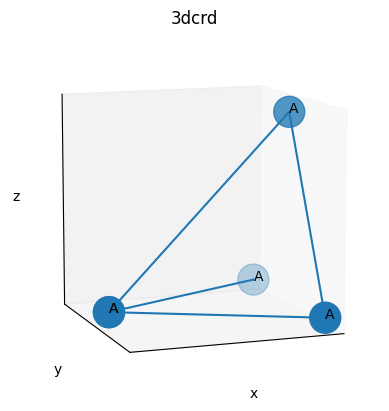

In [ ]:
xyz_coords = result.protein_shape_file_gen.get_xyz_data()
print(xyz_coords)
fig = result.get_figure(title="3dcrd", ticks=False, grid=True)
fig.get_axes()[0].view_init(10, 70)
plt.show()

In [ ]:
def compute_energy(qubit_op, bitstring):
    state = Statevector.from_label(bitstring).data
    energy = state.conj().T @ qubit_op.to_matrix() @ state
    return energy.real

Best turn bitstring:  1000011101011011
Best turn sequence:  [0, 2, 7, 10]
Best turn energy:  6.378231276471524e-14


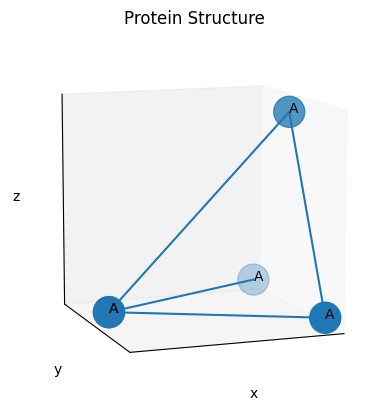

In [ ]:
result = protein_folding_problem.interpret_new(solution)
print("Best turn bitstring: ", result.solution_bitstring)
print("Best turn sequence: ", result.turn_sequence)
print("Best turn energy: ", compute_energy(qubit_op, result.solution_bitstring))
fig = result.get_figure(ticks=False, grid=True)
fig.get_axes()[0].view_init(elev=10, azim=70)

In [ ]:
xyz_coords = result.protein_shape_file_gen.get_xyz_data()
print(xyz_coords)
xyz_coords = xyz_coords[:, 1::]
# Convert the coordinates to float
xyz_coords = xyz_coords.astype(float)
# Compute distances between all pairs of atoms
distances = []
for i in range(len(xyz_coords)):
    for j in range(i + 2, len(xyz_coords)):
        distance = (np.linalg.norm(xyz_coords[i] - xyz_coords[j]) / 3.8 * np.sqrt(2)) ** 2
        distances.append(distance)
print(distances)

[['L' '0.0' '0.0' '0.0']
 ['F' '2.68700576850888' '2.68700576850888' '0.0']
 ['L' '0.0' '2.68700576850888' '-2.68700576850888']
 ['F' '2.68700576850888' '0.0' '-2.68700576850888']]
[1.9999999999999996, 1.9999999999999996, 1.9999999999999996]
